In [1]:
import logging
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from matplotlib.patches import FancyArrowPatch
import matplotlib.patches as patches

import sys
E9path = Path("C:/", "Users", "ken92", "Documents", "Studies", "E5", "simulation", "E9_simulations")
sys.path.insert(1, str(E9path))
import E9_fn.thermodynamics as thmdy
from E9_fn import util
from E9_fn.tight_binding import E9tb
import E9_fn.plane_wave_expansion.blochstate_class as bsc
from projects.flat_band_cooling import helper_fns as hpfn

logpath = '' # '' if not logging to a file
loglevel = logging.INFO
logroot = logging.getLogger()
list(map(logroot.removeHandler, logroot.handlers))
list(map(logroot.removeFilter, logroot.filters))
logging.basicConfig(filename = logpath, level = loglevel)

c:\Users\ken92\Documents\Studies\E5\simulation\E9_simulations\.venv\Lib\site-packages\gftool\precision.py:16: UserWarning: No quad precision datatypes available!
Some functions might be less accurate.
  warnings.warn("No quad precision datatypes available!\n"


In [2]:
lattice_str = "lieb_kagome"
lattice_len = 7
lattice_dim = (lattice_len, lattice_len)
# overwrite_param = {"lat_vec": [np.array([0, 1]), np.array([1, 0])]}
overwrite_param = {}

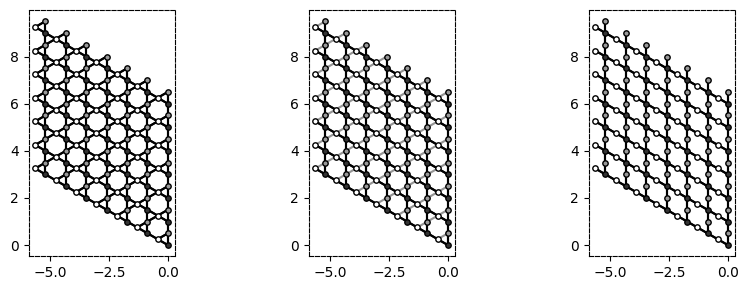

In [3]:
# fig_lat, axes_lat = plt.subplots(1, 3, figsize = (7, 4), width_ratios = [5, 1, 5])
fig, axes = plt.subplots(1, 3, figsize = (9, 3))
tnnn_list = [1, 0.15, 0]

for tnnn, ax in zip(tnnn_list, axes):
    tb_params = E9tb.get_model_params(lattice_str, tnnn = tnnn, overwrite_param = overwrite_param)
    my_tb_model = E9tb.tbmodel_2D(lat_dim = lattice_dim, **tb_params)
    H_total = my_tb_model.H
    my_tb_model.plot_H(ax = ax, H = H_total,
                    sublat_colors = ["#333333", "#999999", "#FFFFFF"],
                    sublat_kwargs = {"edgecolors": "black",
                                        "linewidths": 1})

    # ax.set_xlim(-4.1, -0.2)
    # ax.set_ylim(2.4, 6.3)
    # ax.set_xticks([])
    # ax.set_yticks([])
    ax.spines[:].set_linestyle("--")

fig.tight_layout()

thesis_fig_path = Path(r"C:\Users\ken92\Documents\Studies\E5\Theses\figures\theory")
file_name = "lieb_kagome.pdf"
file_full_path = Path(thesis_fig_path, file_name)
# fig.savefig(file_full_path, facecolor = "none", dpi = 300, bbox_inches='tight')

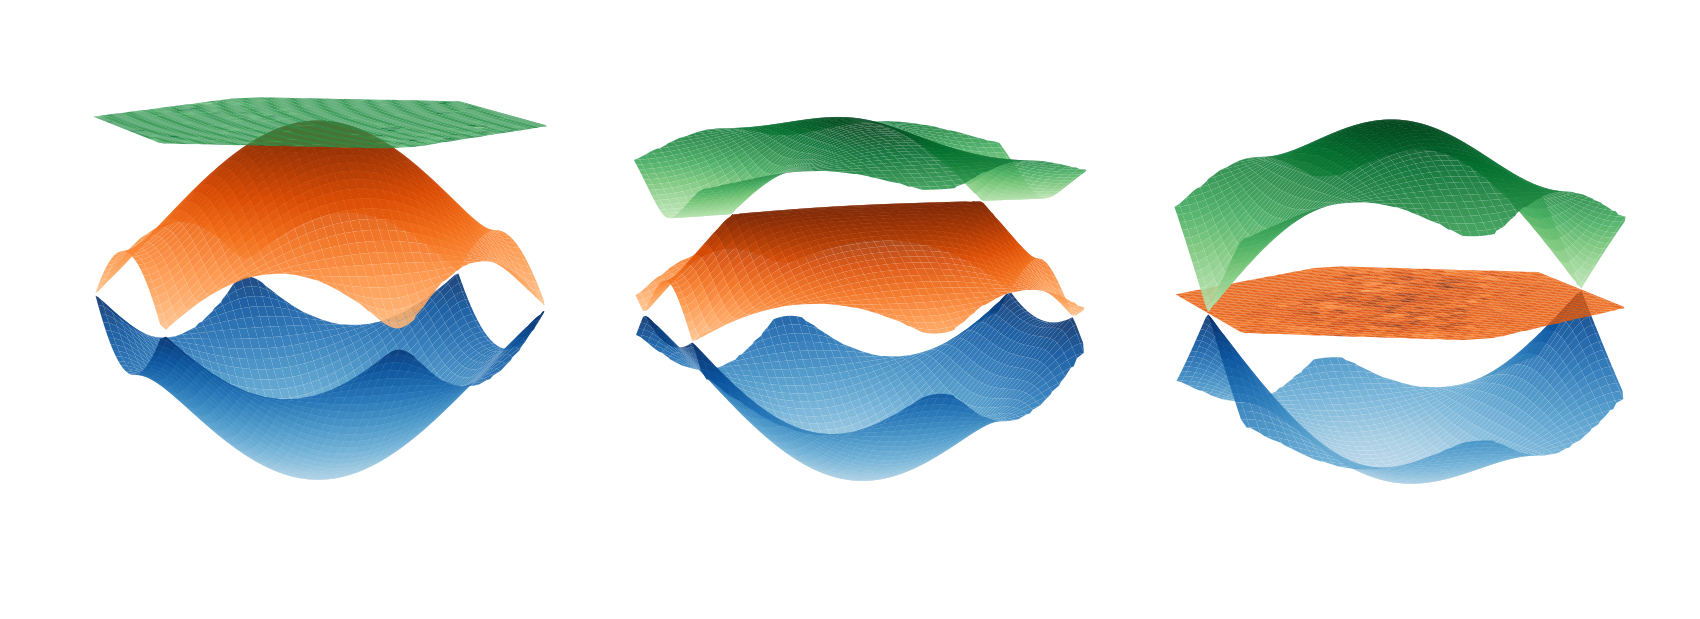

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from mpl_toolkits.mplot3d import Axes3D

# ==========================================
# 1. Real Space & Reciprocal Space Vectors
# ==========================================
a = 1.0  
a1 = a * np.array([1, 0])
a2 = a * np.array([0.5, np.sqrt(3)/2])
a3 = a2 - a1 

area = a1[0]*a2[1] - a1[1]*a2[0]
b1 = 2 * np.pi * np.array([a2[1], -a2[0]]) / area
b2 = 2 * np.pi * np.array([-a1[1], a1[0]]) / area

G_vecs = [b1, b2, b1 + b2, -b1, -b2, -(b1 + b2)]

# ==========================================
# 2. Hamiltonian & FBZ Masking Functions
# ==========================================
def calc_eigenvalues(k, r):
    k_a1 = np.dot(k, a1)
    k_a2 = np.dot(k, a2)
    k_a3 = np.dot(k, a3)
    
    H = -2 * np.array([
        [0,            r * np.cos(k_a1), np.cos(k_a2)],
        [r * np.cos(k_a1), 0,            np.cos(k_a3)],
        [np.cos(k_a2),     np.cos(k_a3),     0           ]
    ])
    
    return np.linalg.eigvalsh(H)

def in_first_bz(k):
    for G in G_vecs:
        if np.dot(k, G) > 0.25 * np.dot(G, G):
            return False
    return True

# ==========================================
# 3. Create Custom Darker Colormaps
# ==========================================
cmap_b = plt.colormaps['Blues']
cmap_o = plt.colormaps['Oranges']
cmap_g = plt.colormaps['Greens']

dark_blues = ListedColormap(cmap_b(np.linspace(0.3, 1, 256)))
dark_oranges = ListedColormap(cmap_o(np.linspace(0.3, 1, 256)))
dark_greens = ListedColormap(cmap_g(np.linspace(0.3, 1, 256)))

# ==========================================
# 4. Create the Grid and Mask
# ==========================================
kx_vals = np.linspace(-2, 2, 150)
ky_vals = np.linspace(-2, 2, 150)

KX, KY = np.meshgrid(kx_vals, ky_vals)

# Pre-calculate the FBZ mask to save processing time
valid_mask = np.zeros_like(KX, dtype=bool)
for i in range(KX.shape[0]):
    for j in range(KX.shape[1]):
        k_point = np.array([KX[i, j], KY[i, j]])
        if in_first_bz(k_point):
            valid_mask[i, j] = True

# ==========================================
# 5. Plotting the Band Structure Side-by-Side
# ==========================================
r_values = [1, 0.5, 0]

fig_bs = plt.figure(figsize=(18, 6))

for idx, r in enumerate(r_values):
    E1 = np.full_like(KX, np.nan)
    E2 = np.full_like(KX, np.nan)
    E3 = np.full_like(KX, np.nan)
    
    for i in range(KX.shape[0]):
        for j in range(KX.shape[1]):
            if valid_mask[i, j]:
                k_point = np.array([KX[i, j], KY[i, j]])
                evals = calc_eigenvalues(k_point, r)
                E1[i, j] = evals[0]
                E2[i, j] = evals[1]
                E3[i, j] = evals[2]
                
    ax = fig_bs.add_subplot(1, 3, idx + 1, projection='3d')
    
    surf1 = ax.plot_surface(KX, KY, E1, cmap=dark_blues, alpha=0.9, antialiased=True)
    surf2 = ax.plot_surface(KX, KY, E2, cmap=dark_oranges, alpha=0.9, antialiased=True)
    surf3 = ax.plot_surface(KX, KY, E3, cmap=dark_greens, alpha=0.9, antialiased=True)
    
    ax.set_axis_off()
    ax.view_init(elev=10, azim=-20)
    
    # NEW: Zoom the camera in to make the surfaces fill more of the invisible bounding box
    # (Requires Matplotlib 3.3 or higher)
    ax.set_box_aspect(None, zoom=1.3)

# NEW: Remove plt.tight_layout() entirely. 
# Explicitly set all outer margins to 0 and use a negative wspace to overlap the boxes.
plt.subplots_adjust(left=0, right=1, bottom=0, top=1, wspace=-0.25)

file_name = "lieb_kagome_band_structure.pdf"
file_full_path = Path(thesis_fig_path, file_name)
# fig_bs.savefig(file_full_path, facecolor = "none", dpi = 300, bbox_inches='tight')